# Repetition-Index Serial Recall Accuracy

> Compute and visualize serial recall accuracy stratified by repetition index.

The repetition-index SRAC analysis measures serial recall accuracy at study positions occupied by repeated items, broken down by repetition index (first occurrence, second occurrence, etc.). This reveals how the benefit of repetition distributes across an item's multiple presentations.

For each study position belonging to a repeated item, the analysis determines which occurrence it represents and checks whether the item was correctly recalled. Accuracy is then aggregated within each repetition index to produce one accuracy value per index.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `mixed_trial_query` | Query string selecting mixed (repeated-item) trials |
| `size` | Maximum presentations per item |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

from jaxcmr.analyses.repsrac import (
    trial_repsrac_counts,
    repsrac,
    plot_repsrac,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = 'data["list_type"] > 2'
size = 2

In [4]:
#| code-summary: Load data
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)

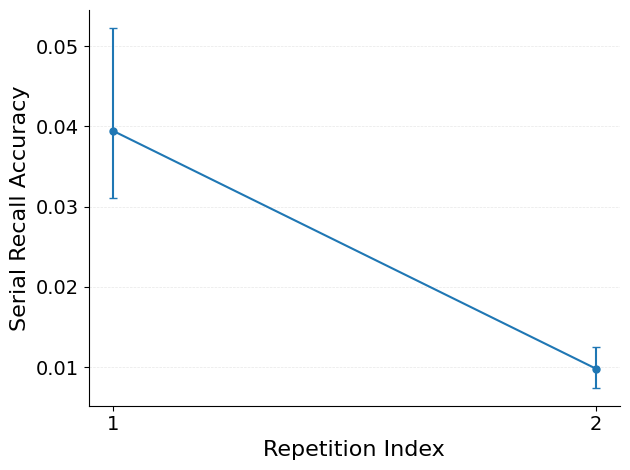

In [5]:
#| code-summary: Plot repetition-index SRAC
#| label: fig-repsrac
#| fig-cap: "Serial recall accuracy by repetition index for repeated items."
plot_repsrac(
    data,
    trial_mask,
    size=size,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="repsrac")

---

## Reference

In [6]:
#| echo: false
show_doc(plot_repsrac)

---

### plot_repsrac

>      plot_repsrac (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],jaxcmr
>                    .typing.RecallDataset], trial_masks:Union[Sequence[jaxtypin
>                    g.Bool[Array,'trial_count']],jaxtyping.Bool[Array,'trial_co
>                    unt']], color_cycle:Optional[list[str]]=None,
>                    labels:Optional[Sequence[str]]=None,
>                    contrast_name:Optional[str]=None,
>                    axis:Optional[matplotlib.axes._axes.Axes]=None, size:int=3,
>                    confidence_level:float=0.95)

*Plot repetition-index serial recall accuracy.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | Recall datasets to plot. |
| trial_masks | Union |  | Boolean masks selecting trials for each dataset. |
| color_cycle | Optional | None | Line colors for each dataset. |
| labels | Optional | None | Legend entries for each dataset. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to draw on. |
| size | int | 3 | Maximum study positions per item. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Axes containing the plot.** |

In [7]:
ax = plot_repsrac(data, trial_mask, size=2)
assert isinstance(ax, Axes)
plt.close()

In [8]:
#| echo: false
show_doc(repsrac)

---

### repsrac

>      repsrac (dataset:jaxcmr.typing.RecallDataset, size:int=3)

*Return recall accuracy for each repetition index.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset with ``recalls`` and<br>``pres_itemnos``. |
| size | int | 3 | Maximum study positions per item. |
| **Returns** | **Float[Array, 'repetition_index']** |  | **Accuracy for each repetition index.** |

In [9]:
result = repsrac(data, size=2)
assert result.shape == (2,)
assert jnp.all(result >= 0.0) and jnp.all(result <= 1.0)

In [10]:
#| echo: false
show_doc(trial_repsrac_counts)

---

### trial_repsrac_counts

>      trial_repsrac_counts
>                            (recalls:jaxtyping.Integer[Array,'recall_positions'
>                            ], presentations:jaxtyping.Integer[Array,'study_pos
>                            itions'], size:int=3)

*Return correct and total counts per repetition index.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| recalls | Integer[Array, 'recall_positions'] |  | Recalled item indices for one trial (1-indexed,<br>0 = no recall). |
| presentations | Integer[Array, 'study_positions'] |  | Item identifiers in study order (1-indexed). |
| size | int | 3 | Maximum study positions per item. |
| **Returns** | **tuple** |  | **Correct counts and total counts per repetition<br>index.** |

In [11]:
correct, total = trial_repsrac_counts(
    data["recalls"][0], data["pres_itemnos"][0], size=2
)
assert correct.shape == (2,)
assert total.shape == (2,)